# Week 4 · Notebook 4 — Diversity, Niching, Island Models and Constraint Handling

**Goals**
- Define and compute genotypic diversity measures (per-locus entropy, mean pairwise distance) and verify the
  exact **genetic-drift** law $E[h_{t+1}] = (1 - 1/N)\,h_t$: a finite GA loses diversity even with *no* selection.
- Implement three **niching** methods — fitness sharing (Goldberg & Richardson 1987), deterministic crowding
  (Mahfoud 1995), clearing (Pétrowski 1996) — and count how many optima of M1 and Himmelblau they locate
  (optima verified independently with `scipy.optimize`).
- Build an **island model** with ring migration and compare it with a panmictic GA at an equal budget.
- Compare **constraint-handling** techniques — death penalty, static and dynamic penalties, greedy repair, Deb's
  feasibility rules (2000), stochastic ranking (Runarsson & Yao 2000) — on 0/1 knapsack (exact optimum from dynamic
  programming) and on the continuous benchmark g06 (optimum re-derived with SLSQP).

**Prerequisites:** Notebooks 1–2 (selection, SBX, polynomial mutation), Lagrangian/KKT basics for Section 5.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from scipy import optimize, stats
from utils import PALETTE, random_knapsack, knapsack_dp, rastrigin

## 1. Premature convergence and how to measure diversity

**Premature convergence**: the population loses the variation needed to reach better regions before it has found
them. It has two causes that are easy to confuse: *selection pressure* (Notebook 1: takeover in
$O(\log N)$ generations) and *genetic drift* — random loss of alleles by finite sampling, which happens even when
all individuals are equally fit.

For a population of $N$ bit strings with $c_\ell$ ones at locus $\ell$ and $p_\ell = c_\ell / N$:

* **per-locus entropy** $H = \frac1L\sum_\ell -p_\ell\log_2 p_\ell - (1-p_\ell)\log_2(1-p_\ell)$ (1 = maximally
  diverse, 0 = converged);
* **mean pairwise Hamming distance** per locus $h = \frac1L\sum_\ell \frac{2c_\ell(N-c_\ell)}{N(N-1)}$ (also the
  average *heterozygosity*).

**Drift law.** Under neutral selection (all fitnesses equal) parents are $N$ i.i.d. uniform draws, so
$c'_\ell \sim \mathrm{Bin}(N, p_\ell)$. Then $E[c'(N-c')] = N(N-1)p(1-p)$, hence

$$E[h_{t+1} \mid P_t] = 2p(1-p) = \left(1 - \tfrac1N\right)h_t, \qquad E[h_t] = \left(1-\tfrac1N\right)^t h_0 .$$

This is the Wright–Fisher result of population genetics (Wright 1931). Uniform crossover does **not** change it:
it swaps alleles between the two children of a pair, so every per-locus allele count is preserved. Crossover
cannot *restore* diversity — only mutation (or migration, Section 3) can.

In [2]:
def entropy_div(P):
    p = P.mean(0)
    with np.errstate(divide="ignore", invalid="ignore"):
        e = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    return float(np.nan_to_num(e).mean())


def pairwise_div(P):
    N = len(P); c = P.sum(0)
    return float((2 * c * (N - c)).sum() / (N * (N - 1)) / P.shape[1])


def neutral_run(N, L, gens, rng, crossover):
    P = rng.random((N, L)) < 0.5
    h = [pairwise_div(P)]; H = [entropy_div(P)]
    for _ in range(gens):
        P = P[rng.integers(0, N, N)]                          # neutral (fitness-blind) selection
        if crossover:
            a, b = P[0::2], P[1::2]
            m = rng.random(a.shape) < 0.5
            P = np.concatenate([np.where(m, b, a), np.where(m, a, b)])
        h.append(pairwise_div(P)); H.append(entropy_div(P))
    return np.array(h), np.array(H)

Nn, Ln, gens_n, R = 30, 60, 80, 200
res_drift = {}
for cx in (False, True):
    runs = [neutral_run(Nn, Ln, gens_n, np.random.default_rng(100 * cx + s), cx) for s in range(R)]
    hh = np.array([r[0] for r in runs]); HH = np.array([r[1] for r in runs])
    res_drift[cx] = (hh, HH)
    ratio = hh.mean(0) / hh[:, 0].mean()
    theory = (1 - 1 / Nn) ** np.arange(gens_n + 1)
    se = hh.std(0) / np.sqrt(R) / hh[:, 0].mean()
    check_true(np.all(np.abs(ratio - theory) < 4 * se + 1e-3),
               f"drift law E[h_t]/h_0 = (1-1/N)^t holds {'with' if cx else 'without'} uniform crossover (4 SE)")

[PASS] drift law E[h_t]/h_0 = (1-1/N)^t holds without uniform crossover (4 SE)


[PASS] drift law E[h_t]/h_0 = (1-1/N)^t holds with uniform crossover (4 SE)


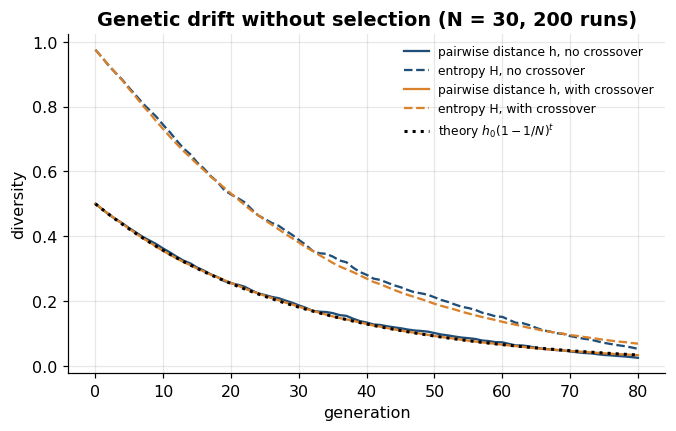

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
tt = np.arange(gens_n + 1)
for cx, col in ((False, PALETTE["blue"]), (True, PALETTE["orange"])):
    hh, HH = res_drift[cx]
    ax.plot(tt, hh.mean(0), color=col, label=f"pairwise distance h, {'with' if cx else 'no'} crossover")
    ax.plot(tt, HH.mean(0), color=col, ls="--", label=f"entropy H, {'with' if cx else 'no'} crossover")
ax.plot(tt, res_drift[False][0][:, 0].mean() * (1 - 1 / Nn) ** tt, "k:", lw=2, label=r"theory $h_0(1-1/N)^t$")
ax.set(xlabel="generation", ylabel="diversity", title=f"Genetic drift without selection (N = {Nn}, {R} runs)")
ax.legend(fontsize=8)
savefig("w4_genetic_drift.png"); plt.show()

## 2. Niching: finding many optima at once

A standard GA converges to *one* optimum even when several are equally good. **Niching** methods maintain
subpopulations on different peaks — useful for multimodal engineering design, for offering a decision-maker
alternatives, and in machine learning for ensembles of diverse models or for quality-diversity search.

* **Fitness sharing** (Goldberg & Richardson 1987): $f'_i = f_i / \sum_j \mathrm{sh}(d_{ij})$ with
  $\mathrm{sh}(d) = 1 - (d/\sigma_{\text{share}})^{\alpha}$ for $d \lt \sigma_{\text{share}}$ and 0 otherwise. At
  equilibrium under proportional selection, the number of individuals on a peak is proportional to its height:
  the population is shared like a resource.
* **Deterministic crowding** (Mahfoud 1995): pair parents at random, create two children, match each child with
  the closer parent ($d(p_1,c_1)+d(p_2,c_2) \le d(p_1,c_2)+d(p_2,c_1)$) and let it replace that parent only if it is
  better. Replacement is local, so peaks do not compete.
* **Clearing** (Pétrowski 1996): within each niche of radius $\sigma_{\text{clear}}$ the best $\kappa$ individuals keep
  their fitness and all others get fitness 0; winners are preserved (elitist).

**Test functions.** M1 $= \sin^6(5\pi x)$ on $[0,1]$ (Goldberg & Richardson 1987; Deb 1989): five equal peaks at
$x = 0.1, 0.3, 0.5, 0.7, 0.9$. Himmelblau $h(x,y) = (x^2+y-11)^2 + (x+y^2-7)^2$ on $[-6,6]^2$: four global minima
with $h = 0$, maximised as $f = 1/(1+h)$. We first verify the optima independently.

In [4]:
m1 = lambda X: np.sin(5 * np.pi * X[..., 0]) ** 6
himm = lambda X: (X[..., 0] ** 2 + X[..., 1] - 11) ** 2 + (X[..., 0] + X[..., 1] ** 2 - 7) ** 2
f_himm = lambda X: 1.0 / (1.0 + himm(X))
M1_PEAKS = np.array([[0.1], [0.3], [0.5], [0.7], [0.9]])
HIMM_MIN = np.array([[3.0, 2.0], [-2.805118, 3.131312], [-3.779310, -3.283186], [3.584428, -1.848126]])

check_close(m1(M1_PEAKS), np.ones(5), "M1 = 1 at the five peaks", atol=1e-12)
refined = []
for x0 in HIMM_MIN + 0.3:
    r = optimize.minimize(lambda z: himm(z), x0, method="BFGS", options={"gtol": 1e-10})
    refined.append(r.x)
refined = np.array(refined)
check_close(np.abs(refined - HIMM_MIN).max(), 0.0, "BFGS (scipy) recovers the four Himmelblau minima: max coordinate error", atol=1e-5)
check_close(himm(refined), np.zeros(4), "Himmelblau value at the minima is 0", atol=1e-10)
grid = np.stack(np.meshgrid(np.linspace(-6, 6, 601), np.linspace(-6, 6, 601)), -1)
hg = himm(grid)
is_min = (hg[1:-1, 1:-1] <= np.minimum.reduce([hg[:-2, 1:-1], hg[2:, 1:-1], hg[1:-1, :-2], hg[1:-1, 2:]])) & (hg[1:-1, 1:-1] < 1.0)
check_true(is_min.sum() == 4, "grid scan of [-6,6]^2: exactly 4 local minima with h < 1 (no other low basins)")

[PASS] M1 = 1 at the five peaks: got [1. 1. 1. 1. 1.], expected [1. 1. 1. 1. 1.]
[PASS] BFGS (scipy) recovers the four Himmelblau minima: max coordinate error: got 1e-06, expected 0.0
[PASS] Himmelblau value at the minima is 0: got [0. 0. 0. 0.], expected [0. 0. 0. 0.]
[PASS] grid scan of [-6,6]^2: exactly 4 local minima with h < 1 (no other low basins)


In [5]:
def sbx_beta(shape, rng, eta):
    u = rng.random(shape)
    return np.where(u <= 0.5, (2 * u) ** (1 / (eta + 1)), (2 * (1 - u)) ** (-1 / (eta + 1)))


def vary(A, B, rng, lo, hi, eta_c=10.0, eta_m=20.0, pc=0.9):
    """SBX (per pair, prob pc) + polynomial mutation (rate 1/d), clipped to the box. Returns 2 children per pair."""
    beta = sbx_beta(A.shape, rng, eta_c)
    do = rng.random((len(A), 1)) < pc
    c1 = np.where(do, 0.5 * ((1 + beta) * A + (1 - beta) * B), A)
    c2 = np.where(do, 0.5 * ((1 - beta) * A + (1 + beta) * B), B)
    C = np.concatenate([c1, c2])
    u = rng.random(C.shape)
    dl = np.where(u < 0.5, (2 * u) ** (1 / (eta_m + 1)) - 1, 1 - (2 * (1 - u)) ** (1 / (eta_m + 1)))
    mut = rng.random(C.shape) < 1.0 / C.shape[1]
    return np.clip(C + mut * dl * (hi - lo), lo, hi)


def sus(w, m, rng):
    c = np.cumsum(w, dtype=float); c = c / c[-1] * m; c[-1] = m
    return np.searchsorted(c, rng.random() + np.arange(m), side="right")


def dist(X, Y):
    return np.sqrt(((X[:, None, :] - Y[None, :, :]) ** 2).sum(-1))


def ga_plain(f, lo, hi, d, rng, N, gens, **_):
    P = rng.uniform(lo, hi, (N, d)); fx = f(P)
    for _ in range(gens):
        T = rng.integers(0, N, (N, 2)); par = P[T[np.arange(N), np.argmax(fx[T], 1)]]
        C = vary(par[0::2], par[1::2], rng, lo, hi); fc = f(C)
        if fx.max() > fc.max():
            w = np.argmin(fc); C[w] = P[np.argmax(fx)]; fc[w] = fx.max()
        P, fx = C, fc
    return P


def ga_sharing(f, lo, hi, d, rng, N, gens, sigma, alpha=1.0):
    P = rng.uniform(lo, hi, (N, d)); fx = f(P)
    for _ in range(gens):
        D = dist(P, P)
        niche = np.where(D < sigma, 1 - (D / sigma) ** alpha, 0.0).sum(1)
        par = P[rng.permutation(sus(fx / niche, N, rng))]
        P = vary(par[0::2], par[1::2], rng, lo, hi); fx = f(P)
    return P


def ga_crowding(f, lo, hi, d, rng, N, gens, **_):
    P = rng.uniform(lo, hi, (N, d)); fx = f(P)
    for _ in range(gens):
        perm = rng.permutation(N); a, b = perm[0::2], perm[1::2]
        C = vary(P[a], P[b], rng, lo, hi); fc = f(C)
        c1, c2, f1, f2 = C[: N // 2], C[N // 2:], fc[: N // 2], fc[N // 2:]
        straight = (np.linalg.norm(P[a] - c1, axis=1) + np.linalg.norm(P[b] - c2, axis=1)
                    <= np.linalg.norm(P[a] - c2, axis=1) + np.linalg.norm(P[b] - c1, axis=1))
        ca, fa = np.where(straight[:, None], c1, c2), np.where(straight, f1, f2)   # child competing with parent a
        cb, fb = np.where(straight[:, None], c2, c1), np.where(straight, f2, f1)
        ra, rb = fa > fx[a], fb > fx[b]
        P[a[ra]], fx[a[ra]] = ca[ra], fa[ra]
        P[b[rb]], fx[b[rb]] = cb[rb], fb[rb]
    return P


def clearing(P, fx, sigma, kappa=1):
    """Pétrowski's clearing: returns cleared fitness and the mask of niche winners."""
    order = np.argsort(-fx)
    fc = fx.copy(); winner = np.zeros(len(P), bool)
    D = dist(P, P)
    alive = np.ones(len(P), bool)
    for i in order:
        if not alive[i]:
            continue
        members = np.flatnonzero(alive & (D[i] < sigma))
        members = members[np.argsort(-fx[members])]
        winner[members[:kappa]] = True
        fc[members[kappa:]] = 0.0
        alive[members] = False
    return fc, winner


def ga_clearing(f, lo, hi, d, rng, N, gens, sigma):
    P = rng.uniform(lo, hi, (N, d)); fx = f(P)
    for _ in range(gens):
        fc, win = clearing(P, fx, sigma)
        elite = np.flatnonzero(win)[: N // 2]
        nkids = N - len(elite)
        par = P[rng.permutation(sus(fc + 1e-12, nkids + nkids % 2, rng))]
        C = vary(par[0::2], par[1::2], rng, lo, hi)[:nkids]
        P = np.concatenate([P[elite], C]); fx = f(P)
    return P


def peaks_found(P, peaks, radius):
    return int((dist(peaks, P).min(1) < radius).sum())

In [6]:
problems = {
    "M1 (5 peaks)": dict(f=m1, lo=0.0, hi=1.0, d=1, N=50, gens=100, sigma=0.1, peaks=M1_PEAKS, radius=0.01),
    "Himmelblau (4 optima)": dict(f=f_himm, lo=-6.0, hi=6.0, d=2, N=80, gens=100, sigma=2.0, peaks=HIMM_MIN, radius=0.1),
}
methods = {"plain GA": ga_plain, "fitness sharing": ga_sharing, "deterministic crowding": ga_crowding,
           "clearing": ga_clearing}
SEEDS = 20
niche_res, final_pops = {}, {}
for pname, pr in problems.items():
    for mname, algo in methods.items():
        counts = []
        for s in range(SEEDS):
            P = algo(pr["f"], pr["lo"], pr["hi"], pr["d"], np.random.default_rng(s), pr["N"], pr["gens"], sigma=pr["sigma"])
            counts.append(peaks_found(P, pr["peaks"], pr["radius"]))
            if s == 0:
                final_pops[(pname, mname)] = P
        niche_res[(pname, mname)] = np.array(counts)
print(f"{'problem':22s} {'method':24s} peaks found: median [IQR]   all found")
for (pname, mname), c in niche_res.items():
    q1, q3 = np.percentile(c, [25, 75])
    print(f"{pname:22s} {mname:24s} {np.median(c):4.1f} [{q1:.1f}, {q3:.1f}]        {np.mean(c == len(problems[pname]['peaks'])):5.0%}")
print(f"(budget: {problems['M1 (5 peaks)']['N'] * 101} evaluations on M1, {problems['Himmelblau (4 optima)']['N'] * 101} on Himmelblau; {SEEDS} seeds)")

problem                method                   peaks found: median [IQR]   all found
M1 (5 peaks)           plain GA                  2.0 [2.0, 3.0]           0%
M1 (5 peaks)           fitness sharing           4.0 [3.0, 4.0]          20%
M1 (5 peaks)           deterministic crowding    5.0 [5.0, 5.0]         100%
M1 (5 peaks)           clearing                  5.0 [5.0, 5.0]         100%
Himmelblau (4 optima)  plain GA                  1.0 [1.0, 1.0]           0%
Himmelblau (4 optima)  fitness sharing           2.0 [1.0, 2.0]           5%
Himmelblau (4 optima)  deterministic crowding    4.0 [4.0, 4.0]         100%
Himmelblau (4 optima)  clearing                  4.0 [4.0, 4.0]         100%
(budget: 5050 evaluations on M1, 8080 on Himmelblau; 20 seeds)


In [7]:
for pname in problems:
    base = niche_res[(pname, "plain GA")]
    for mname in ("fitness sharing", "deterministic crowding", "clearing"):
        p = stats.mannwhitneyu(niche_res[(pname, mname)], base, alternative="greater").pvalue
        check_true(p < 0.01, f"{pname}: {mname} finds more optima than the plain GA (Mann-Whitney p = {p:.1e})")

[PASS] M1 (5 peaks): fitness sharing finds more optima than the plain GA (Mann-Whitney p = 2.7e-04)
[PASS] M1 (5 peaks): deterministic crowding finds more optima than the plain GA (Mann-Whitney p = 2.9e-09)
[PASS] M1 (5 peaks): clearing finds more optima than the plain GA (Mann-Whitney p = 2.9e-09)
[PASS] Himmelblau (4 optima): fitness sharing finds more optima than the plain GA (Mann-Whitney p = 7.9e-04)
[PASS] Himmelblau (4 optima): deterministic crowding finds more optima than the plain GA (Mann-Whitney p = 3.7e-10)
[PASS] Himmelblau (4 optima): clearing finds more optima than the plain GA (Mann-Whitney p = 3.7e-10)


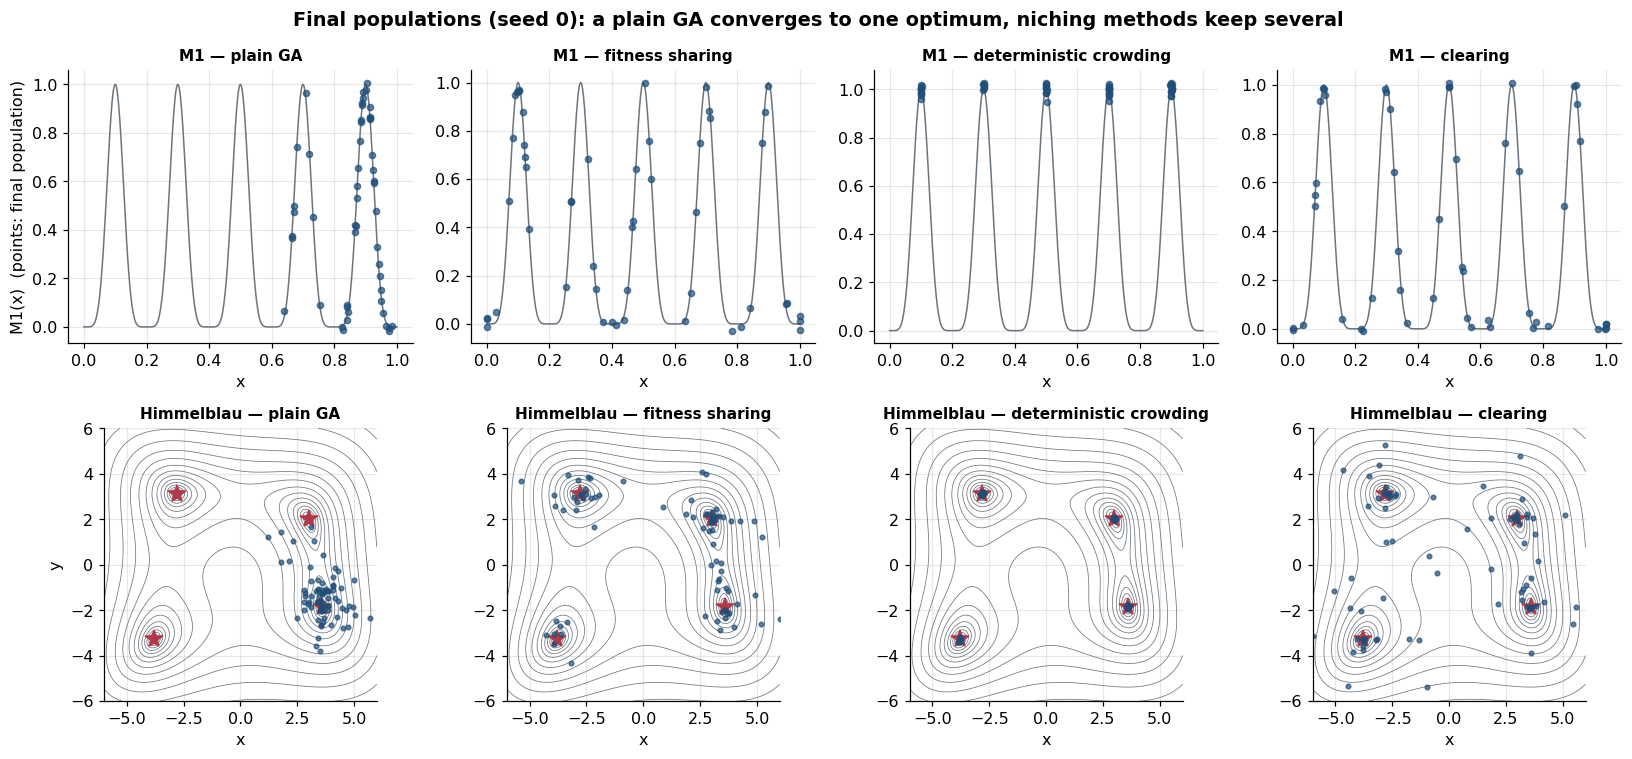

In [8]:
fig, axs = plt.subplots(2, 4, figsize=(15, 7))
xs = np.linspace(0, 1, 500)
Xg, Yg = np.meshgrid(np.linspace(-6, 6, 200), np.linspace(-6, 6, 200))
Hg = np.log1p(himm(np.stack([Xg, Yg], -1)))
for j, mname in enumerate(methods):
    ax = axs[0, j]; P = final_pops[("M1 (5 peaks)", mname)]
    ax.plot(xs, m1(xs[:, None]), color=PALETTE["grey"], lw=1)
    ax.plot(P[:, 0], m1(P) + 0.02 * rng.standard_normal(len(P)), "o", ms=4, alpha=0.7, color=PALETTE["blue"])
    ax.set_title(f"M1 — {mname}", fontsize=10); ax.set_xlabel("x")
    ax = axs[1, j]; P = final_pops[("Himmelblau (4 optima)", mname)]
    ax.contour(Xg, Yg, Hg, levels=15, colors=PALETTE["grey"], linewidths=0.5)
    ax.plot(*HIMM_MIN.T, "*", ms=12, color=PALETTE["red"])
    ax.plot(P[:, 0], P[:, 1], "o", ms=3, alpha=0.7, color=PALETTE["blue"])
    ax.set_title(f"Himmelblau — {mname}", fontsize=10); ax.set_aspect("equal"); ax.set_xlabel("x")
axs[0, 0].set_ylabel("M1(x)  (points: final population)")
axs[1, 0].set_ylabel("y")
fig.suptitle("Final populations (seed 0): a plain GA converges to one optimum, niching methods keep several",
             weight="bold")
fig.tight_layout()
savefig("w4_niching.png"); plt.show()

Deterministic crowding and clearing locate every optimum in every run on both functions, the plain GA finds
two or three peaks of M1 and a single Himmelblau optimum, and fitness sharing sits in between (median 4 of 5 on M1, 2 of 4 on Himmelblau). Sharing and clearing
need a niche radius $\sigma$, i.e. prior knowledge of the distance between optima (here $0.1$ on M1, $2.0$ on
Himmelblau); deterministic crowding needs no radius but relies on the variation operator producing children close
to their parents. Sharing is the weakest here because it only *reshapes* the selection probabilities — with
stochastic sampling and SBX children landing between peaks, niches are still lost by drift (Section 1) — whereas
crowding's local replacement and clearing's preserved niche winners protect each occupied peak explicitly.

## 3. Island models

An **island model** (coarse-grained parallel GA; Grosso 1985; Tanese 1989; Whitley & Starkweather 1990) runs $K$
subpopulations independently and every $\tau$ generations sends the best $m$ individuals of each island to its
neighbour on a ring, replacing the worst there. Isolation lets islands converge to different regions (diversity
*between* islands), migration spreads good material. On a parallel machine each island is one worker, which is
also how distributed evolutionary hyperparameter searches (e.g. population-based training) are organised.

Experiment: Rastrigin in $d = 10$ ($f^{\ast} = 0$ at the origin), real-coded GA (binary tournament, SBX $\eta_c = 10$,
polynomial mutation $\eta_m = 20$, 1-elitism per island), budget $40{,}000$ evaluations, 10 seeds:
panmictic $N = 200$; 4 islands $\times$ 50 with ring migration ($\tau = 10$, $m = 2$); 4 isolated islands $\times$ 50.

In [9]:
def island_ga(f, lo, hi, d, rng, K, n, gens, tau=10, m=2):
    """K islands of size n (K=1: panmictic). tau=None: no migration. Minimisation of f."""
    P = rng.uniform(lo, hi, (K, n, d)); F = np.array([f(Pi) for Pi in P])
    best_trace, div_trace = [], []
    for g in range(1, gens + 1):
        for k in range(K):
            T = rng.integers(0, n, (n, 2)); par = P[k][T[np.arange(n), np.argmin(F[k][T], 1)]]
            C = vary(par[0::2], par[1::2], rng, lo, hi); fc = f(C)
            if F[k].min() < fc.min():
                w = np.argmax(fc); C[w] = P[k][np.argmin(F[k])]; fc[w] = F[k].min()
            P[k], F[k] = C, fc
        if tau is not None and K > 1 and g % tau == 0:
            mig = [np.argsort(F[k])[:m] for k in range(K)]
            out = [(P[k][mig[k]].copy(), F[k][mig[k]].copy()) for k in range(K)]
            for k in range(K):
                src = (k - 1) % K
                worst = np.argsort(F[k])[-m:]
                P[k][worst], F[k][worst] = out[src]
        best_trace.append(F.min())
        allP = P.reshape(-1, d)                         # RMS pairwise distance = sqrt(2 N/(N-1) * sum of variances)
        div_trace.append(np.sqrt(2 * len(allP) / (len(allP) - 1) * allP.var(0).sum()))
    return np.array(best_trace), np.array(div_trace)

d_is, gens_is = 10, 200
configs_is = {"panmictic (1 x 200)": dict(K=1, n=200, tau=None),
              "4 islands x 50, ring migration": dict(K=4, n=50, tau=10),
              "4 isolated islands x 50": dict(K=4, n=50, tau=None)}
is_res = {name: [island_ga(rastrigin, -5.12, 5.12, d_is, np.random.default_rng(s), gens=gens_is, **cfg)
                 for s in range(10)] for name, cfg in configs_is.items()}
print(f"{'configuration':32s} final best f: median [IQR]")
for name, rr in is_res.items():
    fb = np.array([r[0][-1] for r in rr])
    print(f"{name:32s} {np.median(fb):6.2f} [{np.percentile(fb, 25):.2f}, {np.percentile(fb, 75):.2f}]")

configuration                    final best f: median [IQR]
panmictic (1 x 200)                4.60 [3.43, 6.01]
4 islands x 50, ring migration     2.80 [1.40, 3.38]
4 isolated islands x 50            4.27 [2.48, 5.37]


In [10]:
fb = {name: np.array([r[0][-1] for r in rr]) for name, rr in is_res.items()}
for other in ("panmictic (1 x 200)", "4 isolated islands x 50"):
    p = stats.mannwhitneyu(fb["4 islands x 50, ring migration"], fb[other], alternative="less").pvalue
    print(f"ring migration vs {other}: one-sided Mann-Whitney p = {p:.3f}")
check_true(np.median(fb["4 islands x 50, ring migration"]) < min(np.median(fb["panmictic (1 x 200)"]),
                                                                  np.median(fb["4 isolated islands x 50"])),
           "ring-migration island model has the lowest median final value")

ring migration vs panmictic (1 x 200): one-sided Mann-Whitney p = 0.009
ring migration vs 4 isolated islands x 50: one-sided Mann-Whitney p = 0.044
[PASS] ring-migration island model has the lowest median final value


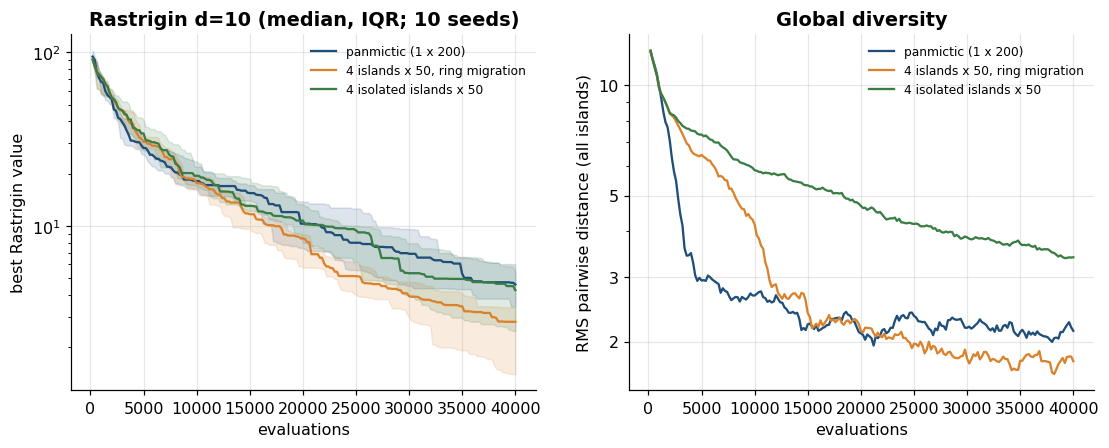

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ev = np.arange(1, gens_is + 1) * 200
for (name, rr), col in zip(is_res.items(), PALETTE.values()):
    B = np.array([r[0] for r in rr]); Dv = np.array([r[1] for r in rr])
    ax[0].plot(ev, np.median(B, 0), color=col, label=name)
    ax[0].fill_between(ev, *np.percentile(B, [25, 75], 0), color=col, alpha=0.15)
    ax[1].plot(ev, np.median(Dv, 0), color=col, label=name)
ax[0].set(yscale="log", xlabel="evaluations", ylabel="best Rastrigin value", title="Rastrigin d=10 (median, IQR; 10 seeds)")
ax[1].set(yscale="log", xlabel="evaluations", ylabel="RMS pairwise distance (all islands)", title="Global diversity")
ax[1].yaxis.set_major_formatter(plt.ScalarFormatter()); ax[1].yaxis.set_minor_formatter(plt.NullFormatter())
ax[1].set_yticks([2, 3, 5, 10])
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
savefig("w4_island_model.png"); plt.show()

On this instance the island model with migration reaches a lower median than both the panmictic GA (one-sided
Mann–Whitney $p \approx 0.01$) and the isolated islands ($p \approx 0.04$ — suggestive, not conclusive, with 10
seeds). The diversity panel shows why: isolated islands keep the most global diversity but each
island is a small, drift-prone population; the panmictic GA converges as one block; periodic migration keeps the
islands apart most of the time while still spreading good material. The size of the effect depends on the
migration interval and topology (Exercise 6), and on a unimodal function the panmictic GA would win — islands buy
robustness on multimodal landscapes at the price of slower convergence.

## 4. Constraint handling on 0/1 knapsack

Maximise $v^\top x$ subject to $w^\top x \le C$, $x \in \lbrace 0,1\rbrace^n$. Violation
$\phi(x) = \max(0, w^\top x - C)$. The techniques differ in how an infeasible $x$ is compared with others:

| Technique | Rule |
|---|---|
| Death penalty | infeasible $\Rightarrow$ fitness $-\infty$ |
| Static penalty | $v^\top x - \rho\,\phi(x)$ with fixed $\rho = \max_i v_i/w_i$ (a common choice: the best value per unit weight) |
| Dynamic penalty (Joines & Houck 1994) | $v^\top x - (c\,t)^{\alpha}\phi(x)^{\beta}$, $c = 0.5$, $\alpha = \beta = 2$, $t$ = generation |
| Greedy repair (Lamarckian) | remove items in increasing $v_i/w_i$ until feasible, write the repaired string back |
| Deb's feasibility rules (Deb 2000) | feasible beats infeasible; two feasible: higher value; two infeasible: smaller $\phi$ |
| Stochastic ranking (Runarsson & Yao 2000) | bubble-sort-like ranking; adjacent pairs compared by objective with probability $P_f = 0.45$ (or if both feasible), otherwise by $\phi$ |

Deb's rules are a *lexicographic* order, so they can be implemented as the scalar key
$\kappa(x) = v^\top x$ if feasible and $\kappa(x) = -\phi(x) - M$ otherwise ($M \gt \sum v$) inside ordinary tournament
selection — no penalty coefficient at all. Stochastic ranking is implemented in its odd–even transposition form
(compare pairs $(0,1),(2,3),\dots$ then $(1,2),(3,4),\dots$ in each sweep), which vectorises the sweeps while
keeping the defining rule; sweeps stop early when nothing is swapped. All methods share the GA of Notebook 1
(binary tournament on the method's key/rank, uniform crossover, bit-flip $1/n$, and 1-elitism that always keeps
the best individual under Deb's order — the same rule for every method, so that no method can lose its best
feasible solution) and are compared
by the **best feasible** value found within $8{,}000$ evaluations (population 40, 10 seeds), relative to the exact
DP optimum.

In [12]:
def stochastic_rank(obj, phi, rng, pf=0.45):
    """Stochastic ranking (Runarsson & Yao 2000), odd-even transposition form.

    Returns indices best-first (maximisation of obj, minimisation of the violation phi). Adjacent individuals are
    compared by objective if both are feasible or with probability pf, otherwise by violation.
    """
    n = len(obj)
    idx, o, ph = np.arange(n), np.asarray(obj, float).copy(), np.asarray(phi, float).copy()
    U = rng.random((n, 2, n // 2))
    for sweep in range(n):
        swapped = False
        for start in (0, 1):
            npairs = (n - start) // 2
            si, sj = slice(start, start + 2 * npairs, 2), slice(start + 1, start + 2 * npairs, 2)
            by_obj = ((ph[si] == 0) & (ph[sj] == 0)) | (U[sweep, start, :npairs] < pf)
            swap = np.where(by_obj, o[si] < o[sj], ph[si] > ph[sj])
            if swap.any():
                swapped = True
                a = start + 2 * np.flatnonzero(swap)
                for arr in (idx, o, ph):
                    arr[a], arr[a + 1] = arr[a + 1].copy(), arr[a].copy()
        if not swapped:
            break
    return idx


def greedy_repair(X, v, w, C):
    """Greedy repair, vectorised: drop selected items in increasing v/w order until the load fits."""
    order = np.argsort(v / w)
    ws = w[order]
    Xs = X[:, order]
    excess = X @ w - C
    before = np.cumsum(Xs * ws, axis=1) - Xs * ws                 # selected weight dropped before item k
    Xs = Xs & ~(Xs & (before < excess[:, None]))
    out = np.empty_like(X); out[:, order] = Xs
    return out


def knap_ga(v, w, C, method, rng, N=40, budget=8_000):
    n = len(v)
    rho = np.max(v / w); Mbig = v.sum() + 1
    repair = lambda X: greedy_repair(X, v, w, C)

    def keys(X, t):
        val, phi = X @ v, np.maximum(0.0, X @ w - C)
        if method == "death penalty":
            return np.where(phi > 0, -np.inf, val)
        if method == "static penalty":
            return val - rho * phi
        if method == "dynamic penalty":
            return val - (0.5 * t) ** 2 * phi**2
        if method in ("Deb's rules", "repair"):
            return np.where(phi > 0, -phi - Mbig, val)
        if method == "stochastic ranking":
            rank = np.empty(len(X)); rank[stochastic_rank(val, phi, rng)] = np.arange(len(X))[::-1]
            return rank

    def deb_key(X):
        phi = np.maximum(0.0, X @ w - C)
        return np.where(phi > 0, -phi - Mbig, X @ v)

    P = rng.random((N, n)) < 0.5
    if method == "repair":
        P = repair(P)
    t, evals = 1, N
    feas_best = lambda X: np.max(np.where(X @ w <= C, X @ v, -np.inf))
    best = feas_best(P)
    while evals + N <= budget:
        k = keys(P, t)
        T = rng.integers(0, N, (N, 2)); par = P[T[np.arange(N), np.argmax(k[T], 1)]]
        a, b = par[0::2], par[1::2]
        msk = rng.random(a.shape) < 0.5
        Cc = np.concatenate([np.where(msk, b, a), np.where(msk, a, b)])
        Cc ^= rng.random(Cc.shape) < 1.0 / n
        if method == "repair":
            Cc = repair(Cc)
        Cc[rng.integers(N)] = P[np.argmax(deb_key(P))]             # 1-elitism, identical for all methods
        P = Cc; t += 1; evals += N
        best = max(best, feas_best(P))
    return best

Before using it, we validate the stochastic-ranking routine on its two limiting cases, where the answer is known
independently: with $P_f = 0$ and all individuals infeasible it must sort by violation; with all individuals
feasible it must sort by objective, whatever $P_f$.

In [13]:
o_t, phi_t = rng.random(40), rng.random(40) + 0.1
check_true(np.array_equal(stochastic_rank(o_t, phi_t, rng, pf=0.0), np.argsort(phi_t)), "stochastic ranking, P_f=0, infeasible: sorted by violation")
check_true(np.array_equal(stochastic_rank(o_t, np.zeros(40), rng, pf=0.45), np.argsort(-o_t)), "stochastic ranking, all feasible: sorted by objective")
Xr = rng.random((200, 100)) < 0.7
wr = rng.integers(1, 101, 100).astype(float); vr = rng.integers(1, 101, 100).astype(float); Cr = 0.4 * wr.sum()
def repair_loop(x):                                                # reference: the textbook sequential loop
    x = x.copy(); load = x @ wr
    for i in np.argsort(vr / wr):
        if load <= Cr:
            break
        if x[i]:
            x[i] = False; load -= wr[i]
    return x
check_true(np.array_equal(greedy_repair(Xr, vr, wr, Cr), np.array([repair_loop(x) for x in Xr])),
           "vectorised greedy repair = sequential textbook loop on 200 random strings")

v_k, w_k, C_k = random_knapsack(100, np.random.default_rng(3), correlation="strong", capacity_ratio=0.5)
opt_k, x_opt = knapsack_dp(v_k, w_k, C_k)
check_true(x_opt @ w_k <= C_k and np.isclose(x_opt @ v_k, opt_k), f"DP optimum {opt_k:.0f} is feasible and consistent")
init_feas = np.mean((np.random.default_rng(1).random((20000, 100)) < 0.5) @ w_k <= C_k)
print(f"fraction of uniformly random strings that are feasible: {init_feas:.3f}")

kmethods = ["death penalty", "static penalty", "dynamic penalty", "repair", "Deb's rules", "stochastic ranking"]
kres = {m: [knap_ga(v_k, w_k, C_k, m, np.random.default_rng(s)) for s in range(10)] for m in kmethods}
print(f"\n{'method':20s} gap to DP optimum (%): median [IQR]   runs with a feasible solution")
kgap = {}
for m in kmethods:
    b = np.array(kres[m])
    gap = 100 * (opt_k - b) / opt_k
    kgap[m] = gap
    print(f"{m:20s} {np.median(gap):7.3f} [{np.percentile(gap, 25):.3f}, {np.percentile(gap, 75):.3f}]     {np.mean(np.isfinite(b)):5.0%}")
check_true(all(np.all(np.array(kres[m]) <= opt_k + 1e-9) for m in kmethods),
           "no method reports a feasible value above the DP optimum")

[PASS] stochastic ranking, P_f=0, infeasible: sorted by violation
[PASS] stochastic ranking, all feasible: sorted by objective
[PASS] vectorised greedy repair = sequential textbook loop on 200 random strings
[PASS] DP optimum 3214 is feasible and consistent
fraction of uniformly random strings that are feasible: 0.500



method               gap to DP optimum (%): median [IQR]   runs with a feasible solution
death penalty          2.209 [1.968, 2.450]      100%
static penalty         1.851 [1.571, 1.867]      100%
dynamic penalty        2.038 [1.711, 2.162]      100%
repair                 0.000 [0.000, 0.000]      100%
Deb's rules            2.007 [1.906, 2.209]      100%
stochastic ranking     1.291 [1.245, 1.797]      100%
[PASS] no method reports a feasible value above the DP optimum


On the knapsack, **greedy repair is in a different league** (the DP optimum in every run): it injects problem
knowledge — the value density $v_i/w_i$, which is also the basis of the LP relaxation — and keeps every
individual on the boundary of the feasible region, where the optimum of a knapsack lies. Among the generic
techniques, stochastic ranking has the smallest median gap and the death penalty the largest; the differences
among static/dynamic penalties and Deb's rules are within the seed-to-seed spread. Half of the random initial
strings are feasible here, so the death penalty is not starved — only wasteful.

## 5. A constrained continuous problem with a known optimum: g06

From the CEC 2006 constrained suite (Liang et al. 2006; originally Floudas & Pardalos 1987):

$$\min\ (x_1-10)^3 + (x_2-20)^3 \quad\text{s.t.}\quad g_1 = -(x_1-5)^2-(x_2-5)^2+100 \le 0,\quad g_2 = (x_1-6)^2+(x_2-5)^2-82.81 \le 0,$$

with $13 \le x_1 \le 100$, $0 \le x_2 \le 100$. The feasible set is a thin crescent between two circles (about
$0.007\%$ of the box), and the optimum lies where both constraints are active:
$f^{\ast} = -6961.81387558\ldots$ at $x^{\ast} \approx (14.095, 0.84296)$. We re-derive it with SLSQP from many starts
and independently by intersecting the two circles in closed form.

In [14]:
g06_f = lambda X: (X[..., 0] - 10) ** 3 + (X[..., 1] - 20) ** 3
g06_g = lambda X: np.stack([-(X[..., 0] - 5) ** 2 - (X[..., 1] - 5) ** 2 + 100,
                            (X[..., 0] - 6) ** 2 + (X[..., 1] - 5) ** 2 - 82.81], -1)
LO6, HI6 = np.array([13.0, 0.0]), np.array([100.0, 100.0])
best_sl = None
for x0 in np.random.default_rng(0).uniform([13, 0], [20, 10], (30, 2)):
    r = optimize.minimize(g06_f, x0, method="SLSQP", bounds=list(zip(LO6, HI6)),
                          constraints=[{"type": "ineq", "fun": lambda x: -g06_g(x)}], options={"ftol": 1e-14, "maxiter": 500})
    if r.success and np.all(g06_g(r.x) <= 1e-8) and (best_sl is None or r.fun < best_sl.fun):
        best_sl = r
# closed form: subtracting the two circle equations gives x1 exactly
x1 = (100 - 82.81 + 36 - 25) / 2                    # (x1-5)^2 - (x1-6)^2 = 100 - 82.81  ->  2 x1 - 11 = 17.19
x2 = 5 - np.sqrt(100 - (x1 - 5) ** 2)               # lower intersection point
f_star = g06_f(np.array([x1, x2]))
print(f"closed form: x* = ({x1:.10f}, {x2:.10f}), f* = {f_star:.8f};  SLSQP: x = {best_sl.x}, f = {best_sl.fun:.8f}")
check_close(best_sl.fun, f_star, "SLSQP optimum = closed-form intersection value", atol=1e-5)
check_close(f_star, -6961.81387558, "g06 optimum matches the published value -6961.81387558", atol=1e-6)
frac = np.mean(np.all(g06_g(np.random.default_rng(2).uniform(LO6, HI6, (2_000_000, 2))) <= 0, axis=1))
print(f"feasible fraction of the box (Monte Carlo, 2e6 points): {100 * frac:.4f}%")

closed form: x* = (14.0950000000, 0.8429607892), f* = -6961.81387558;  SLSQP: x = [14.095       0.84296079], f = -6961.81387558
[PASS] SLSQP optimum = closed-form intersection value: got -6961.813876, expected -6961.813876
[PASS] g06 optimum matches the published value -6961.81387558: got -6961.813876, expected -6961.813876


feasible fraction of the box (Monte Carlo, 2e6 points): 0.0071%


In [15]:
def cont_ga(method, rng, N=30, budget=6_000, pf=0.45):
    """Real-coded GA with (mu+lambda) survivor selection; the constraint-handling method defines the ordering."""
    def order(X):                                                   # indices best-first
        f, phi = g06_f(X), np.maximum(0, g06_g(X)).sum(-1)
        if method == "stochastic ranking":
            return stochastic_rank(-f, phi, rng, pf)
        if method == "death penalty":
            key = np.where(phi > 0, -np.inf, -f)
        elif method == "static penalty":
            key = -(f + 1e4 * phi)
        elif method == "Deb's rules":
            key = np.where(phi > 0, -phi - 1e9, -f)
        return np.argsort(-key, kind="stable")
    P = rng.uniform(LO6, HI6, (N, 2))
    P = P[order(P)]; evals = N
    feas_best = lambda X: np.min(np.where(np.all(g06_g(X) <= 0, -1), g06_f(X), np.inf))
    best = feas_best(P)
    while evals + N <= budget:
        T = rng.integers(0, N, (N, 2)).min(1)                      # P is sorted: smaller index = better
        par = P[T]
        C = vary(par[0::2], par[1::2], rng, LO6, HI6, eta_c=15, eta_m=100)
        evals += N
        best = min(best, feas_best(C))
        U = np.concatenate([P, C])
        P = U[order(U)[:N]]
    return best

cmethods = ["death penalty", "static penalty", "Deb's rules", "stochastic ranking"]
cres = {m: np.array([cont_ga(m, np.random.default_rng(s)) for s in range(10)]) for m in cmethods}
print(f"{'method':20s} f_best - f*: median [IQR]          runs feasible")
for m in cmethods:
    gap = cres[m] - f_star
    fin = np.isfinite(gap)
    q = np.percentile(gap[fin], [25, 50, 75]) if fin.any() else [np.nan] * 3
    print(f"{m:20s} {q[1]:10.4g} [{q[0]:.4g}, {q[2]:.4g}]     {fin.mean():5.0%}   (relative gap {q[1] / abs(f_star):.1%})")
check_true(all(np.all(cres[m][np.isfinite(cres[m])] >= f_star - 1e-6) for m in cmethods),
           "no feasible point better than the verified optimum (sanity of feasibility test)")
check_true(np.mean(np.isfinite(cres["death penalty"])) < min(np.mean(np.isfinite(cres[m])) for m in cmethods[1:]),
           "death penalty finds a feasible point in fewer runs than the ranking-based techniques")

method               f_best - f*: median [IQR]          runs feasible
death penalty             208.4 [208.4, 208.4]       10%   (relative gap 3.0%)
static penalty            440.4 [210, 648.5]      100%   (relative gap 6.3%)
Deb's rules               482.7 [304.6, 580.5]      100%   (relative gap 6.9%)
stochastic ranking        289.7 [262.7, 522.6]      100%   (relative gap 4.2%)
[PASS] no feasible point better than the verified optimum (sanity of feasibility test)
[PASS] death penalty finds a feasible point in fewer runs than the ranking-based techniques


g06 is much harder for a generic GA: the feasible set is $0.007\%$ of the box, and it is a thin curved crescent,
so coordinatewise SBX between two feasible parents usually lands outside it. With the **death penalty** a
population of 30 random points almost never contains a feasible point to start from — most runs never find one
and report nothing. The three techniques that rank infeasible points (static penalty, Deb's rules, stochastic
ranking) always reach the feasible region, but at this small budget none gets within $1\%$ of $f^{\ast}$ (median
relative gaps of 4–7%), and the differences between them are within the spread. (The death penalty's single
feasible run is one sample, not a comparable statistic.) Specialised methods — e.g. the $\varepsilon$-constrained
differential evolution of Takahama & Sakai (2006) — solve g06 to many digits with larger budgets; DE is a Week 6
topic.

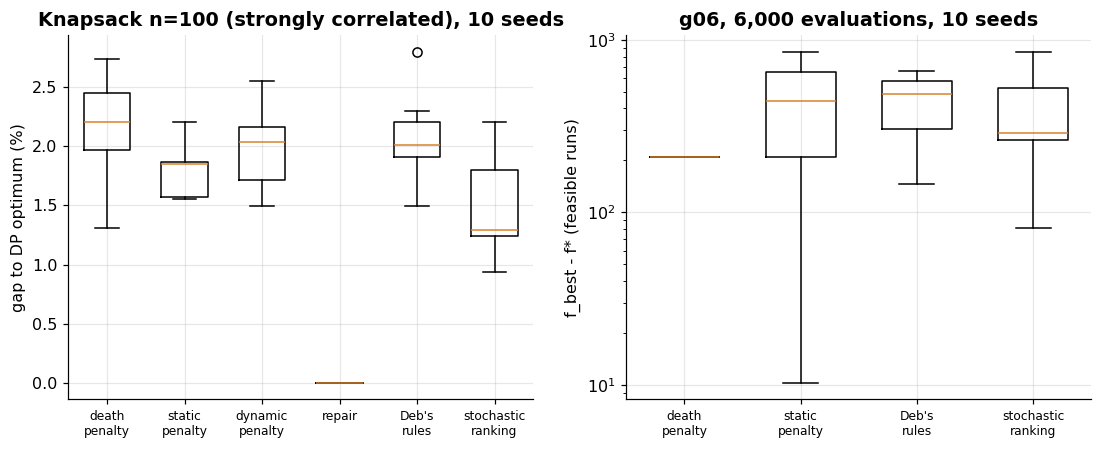

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
pos = np.arange(len(kmethods))
data = [kgap[m][np.isfinite(kgap[m])] for m in kmethods]
ax[0].boxplot(data, positions=pos, widths=0.6)
ax[0].set_xticks(pos, [m.replace(" ", "\n") for m in kmethods], fontsize=8)
ax[0].set(ylabel="gap to DP optimum (%)", title="Knapsack n=100 (strongly correlated), 10 seeds")
data_c = [np.maximum(cres[m][np.isfinite(cres[m])] - f_star, 1e-6) for m in cmethods]
ax[1].boxplot([d if len(d) else [np.nan] for d in data_c], widths=0.6)
ax[1].set_xticks(np.arange(1, len(cmethods) + 1), [m.replace(" ", "\n") for m in cmethods], fontsize=8)
ax[1].set(yscale="log", ylabel="f_best - f* (feasible runs)", title="g06, 6,000 evaluations, 10 seeds")
savefig("w4_constraint_handling.png"); plt.show()

## Key takeaways

- Diversity is lost by selection *and* by drift: even with no selection, a population of $N$ loses heterozygosity
  at rate $1/N$ per generation, and crossover cannot restore it — only mutation, migration or explicit niching can.
- Niching turns "find the optimum" into "find the optima": sharing and clearing need a niche radius, deterministic
  crowding needs children close to parents; all three find far more optima than a plain GA on M1 and Himmelblau.
- Island models trade speed of convergence for diversity between islands; their value depends on the migration
  interval, and they map directly onto parallel hardware.
- Constraint handling is a choice of *order* on infeasible solutions: problem-specific repair and parameter-free
  feasibility rules are robust; penalties need a coefficient; the death penalty wastes evaluations when the feasible
  region is small.

## Exercises

1. ★ Prove the drift law $E[h_{t+1}] = (1-1/N)h_t$ for neutral selection followed by uniform crossover. Then add
   bit-flip mutation with rate $\mu$ after crossover, derive the recursion for $E[h_t]$ and its fixed point
   $h^{\ast}(N, \mu)$, and check both by simulation.
2. ★ Show that with fitness sharing ($\alpha = 1$) and $K$ well-separated peaks of heights $f_1..f_K$ the
   equilibrium niche counts under proportional selection satisfy $n_k \propto f_k$.
3. ★★ Implement *restricted tournament selection* (Harik 1995) and compare it with deterministic crowding on
   Himmelblau and on a 5-D Rastrigin with many optima (count optima within radius 0.1 of the integer lattice).
4. ★★ Prove that Deb's feasibility rules define a total preorder, and show that stochastic ranking with $P_f = 0$
   reduces to it (ranking by violation first, then by objective among feasible solutions).
5. ★★ Vary the static-penalty coefficient $\rho$ over $[0.1, 10] \times \max_i v_i/w_i$ on the knapsack instance and
   plot the gap to the optimum and the fraction of infeasible final populations. Where is the optimum of the
   penalised function infeasible?
6. ★★★ Add migration topology (ring vs fully connected vs random) and interval $\tau \in \lbrace 1, 5, 20, 50\rbrace$ to
   the island model; relate the final diversity to the takeover-time analysis of Notebook 1 applied to the
   *migrants*.